In [ ]:
!pip install opensignalsreader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

file_path = "/content/drive/MyDrive/vallejo/signals/Sentadilla1.txt" # Path del archivo

data = []

with open(file_path, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        values = line.strip().split("\t")
        if len(values) > 5:
            data.append(int(values[5]))

data = np.array(data)

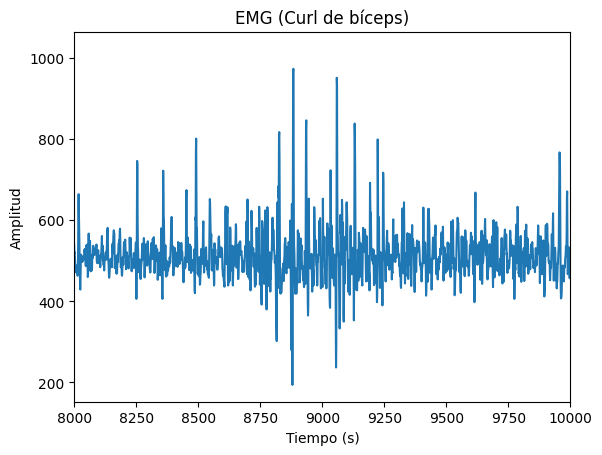

In [ ]:
# Plotear la señal cruda
import matplotlib.pyplot as plt

plt.plot(data)
plt.title("EMG (Curl de bíceps)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(8000,10000)
plt.show()

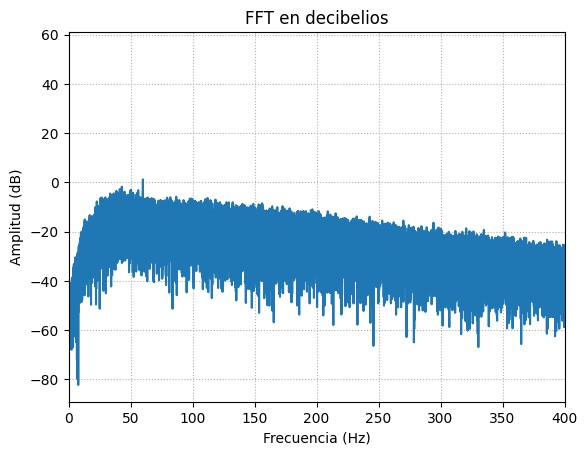

In [ ]:
fs = 1000 # Frecuencia especifica en el archivo (Fs = 1000 Hz)
plt.magnitude_spectrum(data, Fs=fs, scale='dB')

plt.grid(ls=":")
plt.xlim(0,400)
plt.title("FFT en decibelios")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud (dB)")
plt.show()

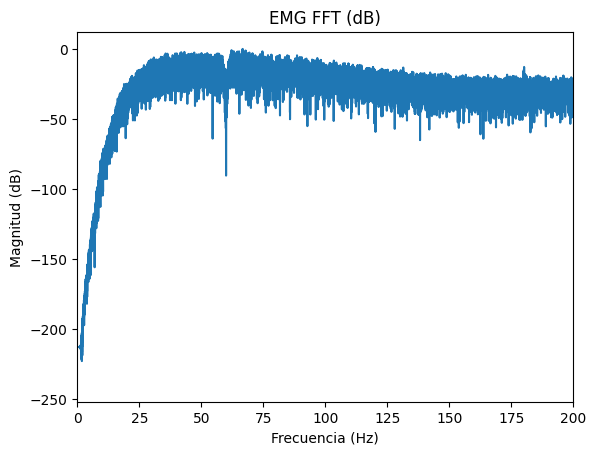

In [ ]:
from scipy.signal import butter, filtfilt, iirnotch
data = data - np.mean(data)  # quitar DC

# =========================
# 4. FILTRO BANDPASS (20–450 Hz)
# =========================
def bandpass_filter(signal, fs, lowcut=20, highcut=450, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# =========================
# 5. FILTRO NOTCH (60 Hz)
# =========================
def notch_filter(signal, fs, f0=60, Q=30):
    w0 = f0 / (fs/2)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, signal)

data_bp = bandpass_filter(data, fs)
data_filt = notch_filter(data_bp, fs)

# =========================
# 6. RECTIFICACIÓN
# =========================
data_rect = np.abs(data_filt)

# =========================
# 7. RMS (250 ms ventana, 125 ms overlap)
# =========================
window_size = int(0.250 * fs)
step = int(0.125 * fs)

rms = []
t_rms = []

for i in range(0, len(data_rect) - window_size, step):
    segment = data_rect[i:i+window_size]
    rms_val = np.sqrt(np.mean(segment**2))

    rms.append(rms_val)
    t_rms.append(i / fs)

rms = np.array(rms)
t_rms = np.array(t_rms)

# =========================
# 8. NORMALIZACIÓN (%CVM)
# =========================
MVC = np.max(rms)
rms_norm = (rms / MVC) * 100

# =========================
# 9. FFT EN dB (sobre señal filtrada)
# =========================
N = len(data_filt)

# ventana para evitar leakage
window = np.hanning(N)
X = np.fft.fft(data_filt * window)

freqs = np.fft.fftfreq(N, d=1/fs)

# magnitud en dB (normalizada)
X_db = 20 * np.log10(np.abs(X)/N + 1e-12)

# solo positivas
mask = freqs >= 0
freqs = freqs[mask]
X_db = X_db[mask]

# =========================
# 10. PLOTS
#
# FFT en dB
plt.figure()
plt.plot(freqs, X_db)
plt.title("EMG FFT (dB)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud (dB)")
plt.xlim(0, 200)
plt.show()